In [67]:
import numpy as np
import matplotlib.pyplot as plt

from typing import Literal

In [68]:
# Default parameters

N=641
L=100.0
cfl=0.5
advection=1.0
sigma=0.8
max_time=50.0

In [69]:
# Initial conditions

def gaussian_pulse(
        grid: np.typing.ArrayLike, center, width) -> np.typing.ArrayLike:
    return np.exp(-((grid - center) / width) ** 2)


def square_wave(
        grid: np.typing.ArrayLike, center, width) -> np.typing.ArrayLike:
    return np.where(np.abs(grid - center) <= width, 1.0, 0.0)


def sine_wave(
        grid: np.typing.ArrayLike, wavenumber: int) -> np.typing.ArrayLike:
    return np.sin(wavenumber * grid)


def left_triangle(grid: np.typing.ArrayLike, l1, l2) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = (grid[mask] - l1) / (l2 - l1)
    return result


def rectangle(grid: np.typing.ArrayLike, l1, l2) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = 1.0
    return result


def wave(grid: np.typing.ArrayLike, l1, l2) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = 0.5 * (1 - np.cos(2 * np.pi * (grid[mask] - l1) / (l2 - l1)))
    return result


def tooth(grid: np.typing.ArrayLike, l1, l2, l11, l22) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)

    mask1 = (grid >= l1) & (grid < l11)
    result[mask1] = -(2/3) * (grid[mask1] - l1) / (l11 - l1) + 1

    mask2 = (grid >= l11) & (grid <= l22)
    result[mask2] = 1/3

    mask3 = (grid > l22) & (grid <= l2)
    result[mask3] = (2/3) * (grid[mask3] - l2) / (l2 - l22) + 1

    return result


def letter_m(grid: np.typing.ArrayLike, l1, l2, l12, l22) -> np.typing.ArrayLike:
    result = np.zeros_like(grid)

    mask1 = (grid >= l1) & (grid < l12)
    result[mask1] = -(2/3) * (grid[mask1] - l1) / (l12 - l1) + 1

    mask2 = (grid >= l22) & (grid <= l2)
    result[mask2] = (2/3) * (grid[mask2] - l2) / (l2 - l22) + 1

    return result


def right_triangle(grid: np.typing.ArrayLike, l1, l2) -> np.typing.ArrayLike:
    """Правый треугольник"""
    result = np.zeros_like(grid)
    mask = (grid >= l1) & (grid <= l2)
    result[mask] = (l2 - grid[mask]) / (l2 - l1)
    return result

In [70]:
BoundaryType = Literal['absorbing', 'periodic', 'fixed', 'extrapolation']

def apply_bc(
        u: np.typing.ArrayLike,
        advection: np.typing.ArrayLike = None,
        bc_type: BoundaryType = 'periodic') -> np.typing.ArrayLike:

    match bc_type:
        case 'absorbing':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-2] = u[-3]
                u[-1] = u[-2]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[1] = u[2]
                u[0] = u[1]
        case 'periodic':
            u[0] = u[-4]
            u[1] = u[-3]
            u[-2] = u[2]
            u[-1] = u[3]
        case 'fixed':
            u[0] = 0.0
            u[1] = 0.0
            u[-2] = 0.0
            u[-1] = 0.0
        case 'extrapolation':
            if advection > 0:
                u[0] = 0.0
                u[1] = 0.0
                u[-1] = 3.0 * u[-2] - 3.0 * u[-3] + u[-4]
                u[-2] = 3.0 * u[-3] - 3.0 * u[-4] + u[-5]
            else:
                u[-1] = 0.0
                u[-2] = 0.0
                u[0] = 3.0 * u[1] - 3.0 * u[2] + u[3]
                u[1] = 3.0 * u[2] - 3.0 * u[3] + u[4]

    return u

In [71]:
def exact_solution(grid: np.typing.ArrayLike, ic_func, ic_kwargs, advection, time, bc_type, L) -> np.typing.ArrayLike:
    shifted = grid - advection * time
    if bc_type == "periodic":
        shifted = shifted % L
    return ic_func(shifted, **ic_kwargs)

In [72]:
import json

def load_coefficients(filename: str = "mlf_coeffs.json"):
    """Load coefficients and return evaluator functions."""
# Usage:    
    # coeffs = load_coefficients("mlf_coeffs.json")
    # c_m2 = coeffs['c_m2'](sigma=0.5, cfl=0.8)
    
    with open(filename, 'r') as f:
        exprs = json.load(f)
    
    def make_evaluator(expr_str: str):
        def evaluate(sigma: float, cfl: float, dx: float) -> float:
            return eval(expr_str, {"sigma": sigma, "cfl": cfl, "np": np, "dx": dx})
        return evaluate
    
    return [make_evaluator(expr) for expr in exprs]


In [73]:
from typing import Any, Callable

coeffs = load_coefficients("mlf_coeffs.json")


def advect(
    N: int = N,
    L: np.floating = L,
    cfl: np.floating = cfl,
    advection: np.floating = advection,
    sigma: np.floating = sigma,
    max_time: np.floating = max_time,
    bc_type="absorbing",
    ic_func: Callable[[np.typing.ArrayLike], np.typing.ArrayLike] = gaussian_pulse,
    ic_kwargs: Any ={"center": 20.0, "width": 5.0},
):
    dx = L / (N - 1.0)
    grid = np.linspace(0.0, (N - 1)*dx, N)

    time = 0.0

    u_exact = ic_func(grid, **ic_kwargs)
    u_rusanov = u_exact.copy()
    u = u_rusanov.copy()

    cfl2 = cfl * cfl
    cfl3 = cfl2 * cfl

    omega = (4.0 * cfl2 + 1.0) * (4.0 - cfl2) / 5.0
    sigma_bar = 1.0 - sigma
    # omega = cfl2 - 1.0

    c_m2, c_m1, c_0, c_p1, c_p2 = map(lambda coeff: coeff(sigma=sigma, cfl=cfl, dx=dx), coeffs)
    # print(c_m2, c_m1, c_0, c_p1, c_p2) # debug
    u_rusanov_new = np.zeros_like(u_rusanov)
    u_new = np.zeros_like(u)

    while time <= max_time:
        dt = dx * cfl / advection
        time += dt
        
        i = np.arange(2, N - 2)
        
        u_rusanov = apply_bc(u_rusanov)
        u_rusanov_new[i] = (
            u_rusanov[i]
            - cfl/12.0 * (-u_rusanov[i+2] + 8.0*u_rusanov[i+1] - 8.0*u_rusanov[i-1] + u_rusanov[i-2])
            + cfl2/8.0 * (u_rusanov[i+2] - 2.0*u_rusanov[i] + u_rusanov[i-2])
            - cfl3/12.0 * (u_rusanov[i+2] - 2.0*u_rusanov[i+1] + 2.0*u_rusanov[i-1] - u_rusanov[i-2])
            - omega/24.0 * (u_rusanov[i+2] - 4.0*u_rusanov[i+1] + 6.0*u_rusanov[i] 
                        - 4.0*u_rusanov[i-1] + u_rusanov[i-2])
        )
        u_rusanov = u_rusanov_new


        u = apply_bc(u)
        u_new[i] = (
            # sigma * u[i] + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
            # - 0.5 * cfl * (u[i+1] - u[i-1])
            # + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
            # - cfl3/12.0 * (u[i+2] - 2.0*u[i+1] + 2.0*u[i-1] - u[i-2])
            # - 1.0/6.0 * (
            #     -(1.0 - sigma)/4.0 * (u[i-2] - 16.0*u[i-1] + 30.0*u[i] - 16.0*u[i+1] + u[i+2])
            #     + 0.5 * cfl * (u[i-2] - 2.0*u[i-1] + 2.0*u[i+1] - u[i+2])
            #     + 0.25 * cfl2 * (u[i-2] - 4.0*u[i-1] + 6.0*u[i] - 4.0*u[i+1] + u[i+2])
            # )

            sigma * u[i]
            + sigma_bar/2 * (u[i+1] + u[i-1])
            - cfl/2 * (u[i+1] - u[i-1])
            + cfl2/2 * (u[i+1] - 2*u[i] + u[i-1])
            # Third-derivative correction
            - advection**3 * dt**3/6 *(
            + c_m2 * u[i-2]
            + c_m1 * u[i-1]
            + c_0  * u[i]
            + c_p1 * u[i+1]
            + c_p2 * u[i+2])
        )
        
        # Fall back to lower-order scheme at non-smooth points (local extrema)
        # oscillation = (u_new[i+1] - u_new[i]) * (u_new[i] - u_new[i-1]) < 0.0
        # u_low = (
        #     sigma * u[i]
        #     + (1.0 - sigma) * 0.5 * (u[i+1] + u[i-1])
        #     - 0.5 * cfl * (u[i+1] - u[i-1])
        #     + 0.5 * cfl2 * (u[i+1] - 2.0 * u[i] + u[i-1])
        # )
        # u_new[i] = np.where(oscillation, u_low, u_new[i])

        u = u_new
    
    u_exact = exact_solution(grid, ic_func, ic_kwargs, advection, time, bc_type, L)

    return grid, u, u_rusanov, u_exact

In [74]:
grid, u, u_rusanov, u_exact = advect(
        ic_func=gaussian_pulse,
        ic_kwargs={"center": 20.0, "width": 5.0},
    )
dx = L / (N - 1.0)

error_rusanov = u_rusanov - u_exact
error = np.abs(u - u_exact)


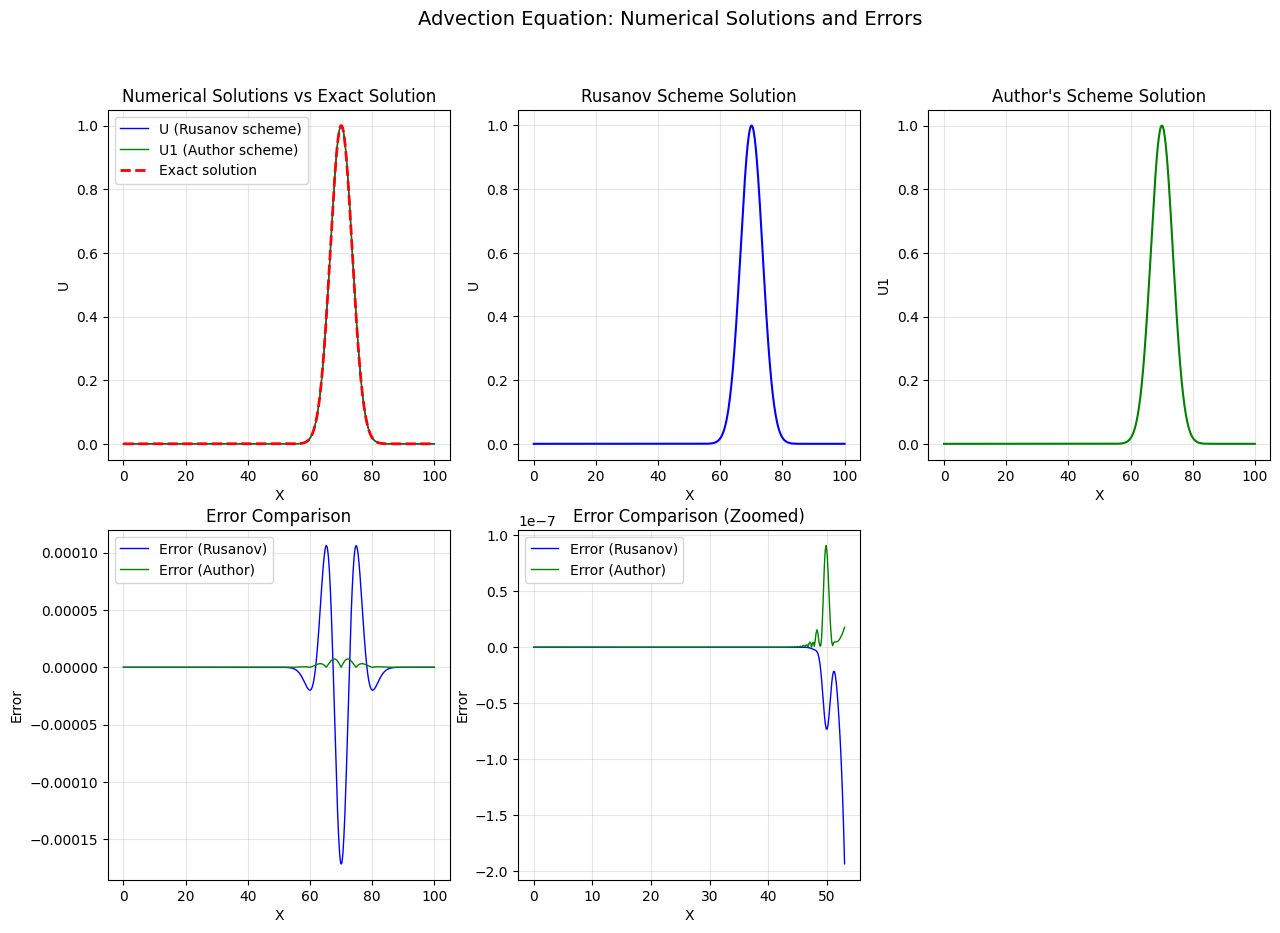

In [75]:

# Create a figure with multiple subplots
plt.figure(figsize=(15, 10))

# Plot 1: Numerical solutions and exact solution
plt.subplot(2, 3, 1)
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='U (Rusanov scheme)')
plt.plot(grid, u, 'g-', linewidth=1, label='U1 (Author scheme)')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlabel('X')
plt.ylabel('U')
plt.title('Numerical Solutions vs Exact Solution')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Rusanov scheme solution
plt.subplot(2, 3, 2)
plt.plot(grid, u_rusanov, 'b-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U')
plt.title('Rusanov Scheme Solution')
plt.grid(True, alpha=0.3)

# Plot 3: Author's scheme solution
plt.subplot(2, 3, 3)
plt.plot(grid, u, 'g-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U1')
plt.title("Author's Scheme Solution")
plt.grid(True, alpha=0.3)

# Plot 4: Error comparison
plt.subplot(2, 3, 4)
plt.plot(grid, error_rusanov, 'b-', linewidth=1, label='Error (Rusanov)')
plt.plot(grid, error, 'g-', linewidth=1, label='Error (Author)')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Error Comparison')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 5: Zoomed error comparison (first 100 points)
plt.subplot(2, 3, 5)
n_el = int(advection * max_time / dx) + 20
plt.plot(grid[:n_el], error_rusanov[:n_el], 'b-', linewidth=1, label='Error (Rusanov)')
plt.plot(grid[:n_el], error[:n_el], 'g-', linewidth=1, label='Error (Author)')
plt.xlabel('X')
plt.ylabel('Error')
plt.title('Error Comparison (Zoomed)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.suptitle(f'Advection Equation: Numerical Solutions and Errors', fontsize=14)
# plt.tight_layout()

plt.show()

In [76]:
N_values = [51, 101, 201, 401, 801, 1601]

errors_rusanov_Linf = []
errors_rusanov_L1 = []
errors_rusanov_L2 = []

errors_method_Linf = []
errors_method_L1 = []
errors_method_L2 = []

dxs = []

for N_val in N_values:
    dx = L / (N_val - 1.0)
    dxs.append(dx)

    grid, u, u_rusanov, u_exact = advect(
        N=N_val,
        sigma=0.9,
        cfl=0.5,
        max_time=20,
        ic_func=gaussian_pulse,
        ic_kwargs={"center": 20.0, "width": 5.0},
    )

    err_rus = np.abs(u_rusanov - u_exact)
    errors_rusanov_Linf.append(np.max(err_rus))
    errors_rusanov_L1.append(np.sum(err_rus) * dx)
    errors_rusanov_L2.append(np.sqrt(np.sum(err_rus**2) * dx))

    err = np.abs(u - u_exact)
    errors_method_Linf.append(np.max(err))
    errors_method_L1.append(np.sum(err) * dx)
    errors_method_L2.append(np.sqrt(np.sum(err**2) * dx))

dxs = np.array(dxs)

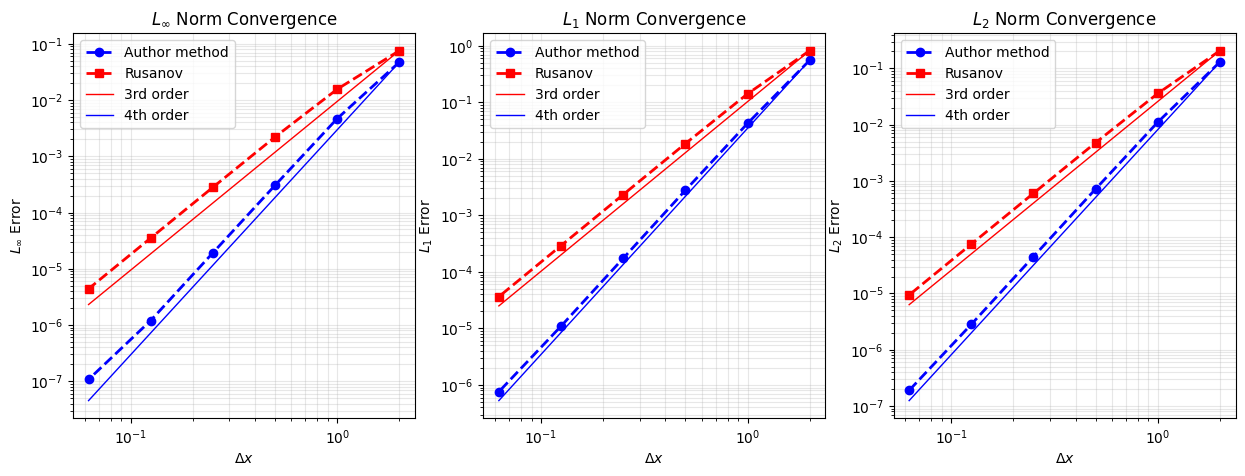

In [77]:
from matplotlib.axes import Axes


fig, axes = plt.subplots(1, 3, figsize=(15, 5))
norm_names = ['$L_{\infty}$', '$L_1$', '$L_2$']
errors_method_all = [errors_method_Linf, errors_method_L1, errors_method_L2]
errors_rusanov_all = [errors_rusanov_Linf, errors_rusanov_L1, errors_rusanov_L2]

for ax, name, err_m, err_r in zip(axes, norm_names, errors_method_all, errors_rusanov_all):
    ax: Axes
    ax.loglog(dxs, err_m, 'bo--', label='Author method', linewidth=2)
    ax.loglog(dxs, err_r, 'rs--', label='Rusanov', linewidth=2)

    # Reference slopes
    slope = (dxs / dxs[0])
    # debug
    # for order in [1, 2, 3, 4, 5]:
        # ax.loglog(dxs, err_m[0] * slope**order, label=f"{order}-{'nd' if order < 2 else 'th'} order")

    ax.loglog(dxs, err_r[0] * slope**3, label='3rd order', color ='red', linewidth=1)
    ax.loglog(dxs, err_m[0] * slope**4, label='4th order', color='blue', linewidth=1)

    ax.set_xlabel(r'$\Delta x$')
    ax.set_ylabel(f'{name} Error')
    ax.set_title(f'{name} Norm Convergence')
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)

plt.show()

In [78]:
grid, u, u_rusanov, u_exact = advect(
    max_time=10,
    ic_func=rectangle,
    ic_kwargs={"l1": 15.0, "l2": 25.0},
)

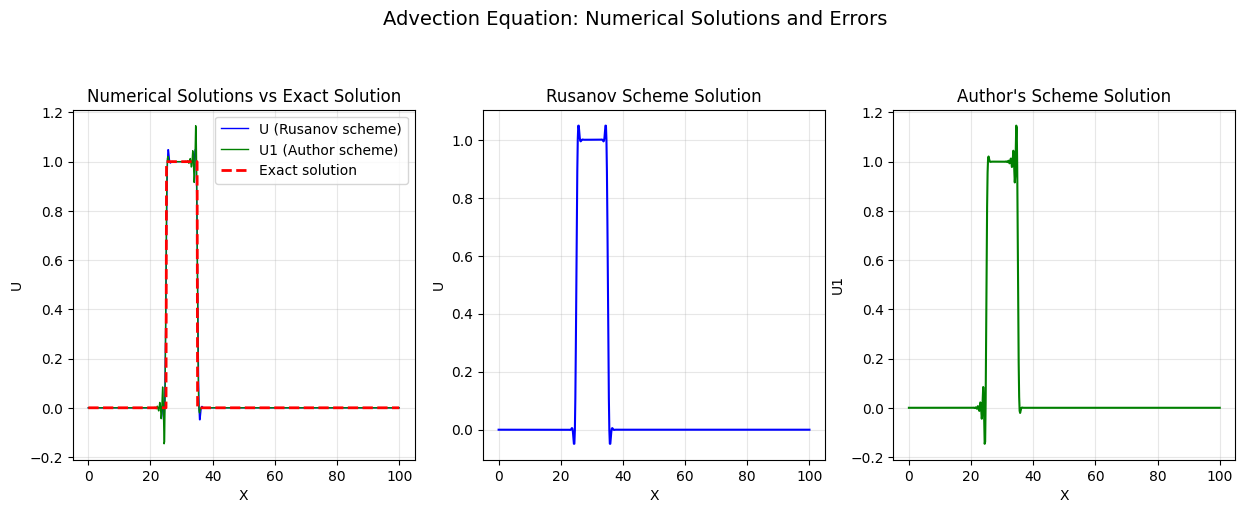

In [79]:
plt.figure(figsize=(15, 10))

# Plot 1: Numerical solutions and exact solution
plt.subplot(2, 3, 1)
plt.plot(grid, u_rusanov, 'b-', linewidth=1, label='U (Rusanov scheme)')
plt.plot(grid, u, 'g-', linewidth=1, label='U1 (Author scheme)')
plt.plot(grid, u_exact, 'r--', linewidth=2, label='Exact solution')
plt.xlabel('X')
plt.ylabel('U')
plt.title('Numerical Solutions vs Exact Solution')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Rusanov scheme solution
plt.subplot(2, 3, 2)
plt.plot(grid, u_rusanov, 'b-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U')
plt.title('Rusanov Scheme Solution')
plt.grid(True, alpha=0.3)

# Plot 3: Author's scheme solution
plt.subplot(2, 3, 3)
plt.plot(grid, u, 'g-', linewidth=1.5)
plt.xlabel('X')
plt.ylabel('U1')
plt.title("Author's Scheme Solution")
plt.grid(True, alpha=0.3)


plt.suptitle('Advection Equation: Numerical Solutions and Errors', fontsize=14)

plt.show()